In [1]:
from sandbox.plt_dict import matplotlib_update
matplotlib_update()

In [2]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def load_results_csvs(folder_path):
    """
    Reads all CSV files named results_{d}.csv (d = 1 or 2 digits)
    from the given folder and returns a dict of DataFrames.

    Returns:
        dict[int, pd.DataFrame]: {d: dataframe}
    """
    pattern = re.compile(r"^results_(\d{1,2})\.csv$")
    data = {}

    for filename in os.listdir(folder_path):
        match = pattern.match(filename)
        if match:
            d = int(match.group(1))
            file_path = os.path.join(folder_path, filename)
            df = pd.read_csv(file_path)
            data[d] = df

    return data

In [4]:
results = load_results_csvs("./sandbox/jordan8_results")

In [5]:
results[28].describe()

,true_class,pred_class,kl_loss,E_norm,S_cond,rad
count,280000.000000,280000.000000,280000.000000,280000.000000,280000.000000,280000.000000
mean,13.500000,13.500364,0.060238,0.006711,252.081035,0.389390
std,8.077762,8.077223,0.187169,0.017028,511.723409,0.255200
min,0.000000,0.000000,0.000001,0.000000,12.118155,0.000000
25%,6.750000,7.000000,0.002550,0.000001,56.886024,0.164374
50%,13.500000,14.000000,0.007209,0.000056,99.234824,0.413866
75%,20.250000,21.000000,0.030788,0.002419,211.447916,0.585677
max,27.000000,27.000000,11.095610,0.099997,5598.532682,0.947335


In [6]:

def _assign_bins(series, bins):
    """
    Assign values to bins. Returns a categorical Series.
    """
    # Convert custom bin format into edges
    edges = [-np.inf]
    labels = []

    for b in bins:
        if isinstance(b, tuple):
            low, high = b
        else:
            # single value like (0)
            low, high = b, b

        edges.append(high)
        labels.append(f"{low:g}-{high:g}")

    edges[-1] = np.inf  # last bin open-ended

    return pd.cut(series, bins=edges, labels=labels, include_lowest=True)


def compute_metrics_by_E(
    results_dict,
    bins=None,
    k=0  # for accuracy@±k
):
    """
    Computes:
      - avg KL loss
      - accuracy
      - accuracy@±k

    grouped by dimension d and E_norm bins.

    Returns:
        metrics_df: pd.DataFrame (multi-metric)
        counts_df: pd.DataFrame (#samples per bin)
    """

    if bins is None:
        bins = [
            0,
            (1e-8, 1e-7),
            (1e-7, 1e-6),
            (1e-6, 1e-5),
            (1e-5, 1e-4),
            (1e-4, 1e-3),
            (1e-3, 1e-2),
            (1e-2, 1e-1),
        ]

    metrics_rows = []
    counts_rows = []

    for d, df in results_dict.items():
        df = df.copy()

        # Assign bins
        df["E_bin"] = _assign_bins(df["E_norm"], bins)

        # Metrics
        df["correct"] = df["true_class"] == df["pred_class"]
        df["correct_k"] = (df["true_class"] - df["pred_class"]).abs() <= k

        grouped = df.groupby("E_bin")

        avg_kl = grouped["kl_loss"].mean()
        acc = grouped["correct"].mean()
        acc_k = grouped["correct_k"].mean()
        counts = grouped.size()

        # Combine metrics
        metrics = pd.concat(
            {
                "avg_kl": avg_kl,
                "accuracy": acc,
                f"accuracy@±{k}": acc_k,
            },
            axis=1,
        )

        metrics["d"] = d
        counts = counts.to_frame(name="count")
        counts["d"] = d

        metrics_rows.append(metrics.reset_index())
        counts_rows.append(counts.reset_index())

    # Merge all
    metrics_df = pd.concat(metrics_rows)
    counts_df = pd.concat(counts_rows)

    # Pivot into final table form
    metrics_df = metrics_df.pivot(index="d", columns="E_bin")
    counts_df = counts_df.pivot(index="d", columns="E_bin", values="count")

    # Sort rows by d
    metrics_df = metrics_df.sort_index()
    counts_df = counts_df.sort_index()

    return metrics_df, counts_df

In [7]:
def compute_metrics_by_rad(
    results_dict,
    bin_edges=None,
    k=0
):
    """
    Computes:
      - avg KL loss
      - accuracy
      - accuracy@±k

    grouped by dimension d and rad bins.

    Args:
        results_dict: dict[int, pd.DataFrame]
        bin_edges: list of bin edges (including interior points)
        k: tolerance for accuracy@±k

    Returns:
        metrics_df: pd.DataFrame (multi-index columns)
        counts_df: pd.DataFrame
    """

    if bin_edges is None:
        bin_edges = [1e-8, 0.1, 0.4, 0.7]

    # Build full edges with open ends
    edges = [0] + bin_edges + [1]

    # Create readable labels
    labels = [
        f"{edges[i]:g}-{edges[i+1]:g}"
        for i in range(len(edges) - 1)
    ]

    metrics_rows = []
    counts_rows = []

    for d, df in results_dict.items():
        df = df.copy()

        # Bin rad
        df["rad_bin"] = pd.cut(
            df["rad"],
            bins=edges,
            labels=labels,
            include_lowest=True
        )

        # Metrics
        df["correct"] = df["true_class"] == df["pred_class"]
        df["correct_k"] = (df["true_class"] - df["pred_class"]).abs() <= k

        grouped = df.groupby("rad_bin")

        avg_kl = grouped["kl_loss"].mean()
        acc = grouped["correct"].mean()
        acc_k = grouped["correct_k"].mean()
        counts = grouped.size()

        metrics = pd.concat(
            {
                "avg_kl": avg_kl,
                "accuracy": acc,
                f"accuracy@±{k}": acc_k,
            },
            axis=1,
        )

        metrics["d"] = d
        counts = counts.to_frame(name="count")
        counts["d"] = d

        metrics_rows.append(metrics.reset_index())
        counts_rows.append(counts.reset_index())

    # Combine all d
    metrics_df = pd.concat(metrics_rows)
    counts_df = pd.concat(counts_rows)

    # Pivot
    metrics_df = metrics_df.pivot(index="d", columns="rad_bin")
    counts_df = counts_df.pivot(index="d", columns="rad_bin", values="count")

    # Sort by dimension
    metrics_df = metrics_df.sort_index()
    counts_df = counts_df.sort_index()

    return metrics_df, counts_df

In [8]:
bins = [
            0,
            (1e-12, 1e-3),
            (1e-3, 1e-2),
            (1e-2, 1e-1),
        ]

metrics, counts = compute_metrics_by_E(results, k=1, bins=bins)

C:\Users\micha\AppData\Local\Temp\ipykernel_6460\4467715.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("E_bin")
C:\Users\micha\AppData\Local\Temp\ipykernel_6460\4467715.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("E_bin")
C:\Users\micha\AppData\Local\Temp\ipykernel_6460\4467715.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("E_bin")
C:\U

In [9]:
counts

E_bin,0-0,1e-12-0.001,0.001-0.01,0.01-0.1
d,,,,
4,3453,26108,5232,5207
6,4241,39059,8237,8463
7,5112,45427,9724,9737
9,6041,58377,12853,12729
12,7014,76961,18134,17891
13,7934,83496,19192,19378
15,9077,96169,22249,22505
16,8187,102005,24979,24829
19,10937,121694,28806,28563


In [10]:
metrics[["avg_kl", "accuracy", "accuracy@±1"]].round(3)

avg_kl                                 accuracy                         \
E_bin    0-0 1e-12-0.001 0.001-0.01 0.01-0.1      0-0 1e-12-0.001 0.001-0.01   
d                                                                              
4      0.052       0.168      0.010    0.016    0.999       0.999      0.980   
6      0.042       0.149      0.010    0.030    0.999       0.999      0.986   
7      0.055       0.213      0.028    0.046    1.000       0.999      0.954   
9      0.035       0.119      0.005    0.032    1.000       1.000      0.990   
12     0.010       0.104      0.009    0.031    1.000       1.000      0.987   
13     0.060       0.221      0.137    0.127    0.999       0.988      0.856   
15     0.006       0.098      0.005    0.029    1.000       1.000      0.993   
16     0.029       0.260      0.127    1.114    1.000       0.982      0.801   
19     0.032       0.188      0.032    0.095    1.000       0.990      0.905   
23     0.036       0.181      0.063    0.286    1.000       0.989      0.896   
25     0.019       0.200      0.082    0.175    1.000       0.993      0.886   
27     0.003       0.104      0.007    0.140    1.000       1.000      0.994   
28     0.002       0.082      0.007    0.046    1.000       1.000      0.992   
29     0.014       0.327      0.425    2.345    1.000       0.999      0.941   
33     0.011       0.108      0.047    0.125    1.000       0.996      0.946   
35     0.024       0.134      0.050    0.143    1.000       0.993      0.947   

               accuracy@±1                                  
E_bin 0.01-0.1         0-0 1e-12-0.001 0.001-0.01 0.01-0.1  
d                                                           
4        0.807         1.0         1.0      1.000    0.996  
6        0.841         1.0         1.0      1.000    0.980  
7        0.797         1.0         1.0      0.999    0.972  
9        0.887         1.0         1.0      1.000    0.982  
12       0.879         1.0         1.0      0.999    0.985  
13       0.658         1.0         1.0      0.999    0.934  
15       0.897         1.0         1.0      1.000    0.985  
16       0.507         1.0         1.0      0.978    0.764  
19       0.750         1.0         1.0      0.999    0.955  
23       0.730         1.0         1.0      0.997    0.942  
25       0.753         1.0         1.0      0.996    0.938  
27       0.855         1.0         1.0      0.999    0.944  
28       0.892         1.0         1.0      1.000    0.977  
29       0.549         1.0         1.0      0.971    0.690  
33       0.767         1.0         1.0      0.997    0.941  
35       0.784         1.0         1.0      0.997    0.943

In [11]:
bin_edges = [1e-8, 0.25, 0.5, 0.75]


metrics_rad, counts_rad = compute_metrics_by_rad(results, k=1, bin_edges=bin_edges)

C:\Users\micha\AppData\Local\Temp\ipykernel_6460\1770609175.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("rad_bin")
C:\Users\micha\AppData\Local\Temp\ipykernel_6460\1770609175.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("rad_bin")
C:\Users\micha\AppData\Local\Temp\ipykernel_6460\1770609175.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(

In [12]:
counts_rad

rad_bin,0-1e-08,1e-08-0.25,0.25-0.5,0.5-0.75,0.75-1
d,,,,,
4,3709,34807,1457,27,0
6,4497,49806,5076,621,0
7,5400,55898,7427,1275,0
9,6308,66343,13632,3695,22
12,7324,75616,27083,9576,401
13,8229,77180,31772,12027,792
15,9389,78004,42903,17816,1888
16,8474,76636,50388,21933,2569
19,11286,77381,63123,32569,5641


In [13]:
metrics_rad[["avg_kl", "accuracy", "accuracy@±1"]].round(3)

avg_kl                                     accuracy             \
rad_bin 0-1e-08 1e-08-0.25 0.25-0.5 0.5-0.75 0.75-1  0-1e-08 1e-08-0.25   
d                                                                         
4         0.051      0.129    0.012    0.012    NaN    0.999      0.974   
6         0.042      0.120    0.030    0.022    NaN    0.999      0.984   
7         0.054      0.176    0.065    0.058    NaN    1.000      0.982   
9         0.035      0.103    0.032    0.043  0.081    1.000      0.995   
12        0.010      0.086    0.067    0.035  0.053    1.000      0.994   
13        0.061      0.155    0.304    0.148  0.168    0.999      0.964   
15        0.007      0.080    0.080    0.025  0.082    1.000      0.996   
16        0.029      0.117    0.430    0.870  2.941    1.000      0.968   
19        0.033      0.101    0.218    0.115  0.211    1.000      0.992   
23        0.038      0.127    0.156    0.162  0.739    1.000      0.979   
25        0.021      0.151    0.138    0.232  0.292    1.000      0.996   
27        0.003      0.067    0.064    0.126  0.204    1.000      0.996   
28        0.003      0.069    0.052    0.068  0.076    1.000      0.999   
29        0.015      0.136    0.137    0.886  3.285    1.000      0.971   
33        0.012      0.138    0.068    0.080  0.170    1.000      0.987   
35        0.025      0.124    0.057    0.143  0.183    1.000      0.993   

                                 accuracy@±1                               \
rad_bin 0.25-0.5 0.5-0.75 0.75-1     0-1e-08 1e-08-0.25 0.25-0.5 0.5-0.75   
d                                                                           
4          0.856    0.889    NaN         1.0      0.999    0.999    0.963   
6          0.879    0.837    NaN         1.0      0.999    0.980    0.998   
7          0.848    0.712    NaN         1.0      0.999    0.976    0.984   
9          0.962    0.805  0.591         1.0      0.999    0.993    0.971   
12         0.984    0.857  0.489         1.0      1.000    0.998    0.981   
13         0.910    0.640  0.472         1.0      0.999    0.990    0.926   
15         0.994    0.934  0.596         1.0      1.000    0.999    0.989   
16         0.905    0.558  0.165         1.0      0.996    0.976    0.854   
19         0.974    0.805  0.553         1.0      1.000    0.999    0.986   
23         0.991    0.869  0.514         1.0      1.000    0.999    0.992   
25         0.994    0.895  0.512         1.0      1.000    1.000    0.994   
27         0.997    0.987  0.762         1.0      1.000    0.999    0.995   
28         0.999    0.994  0.810         1.0      1.000    1.000    0.999   
29         0.966    0.941  0.495         1.0      0.996    0.989    0.959   
33         0.981    0.979  0.721         1.0      1.000    1.000    0.998   
35         0.995    0.972  0.737         1.0      1.000    1.000    0.999   

                
rad_bin 0.75-1  
d               
4          NaN  
6          NaN  
7          NaN  
9        0.955  
12       0.983  
13       0.929  
15       0.945  
16       0.328  
19       0.864  
23       0.863  
25       0.863  
27       0.907  
28       0.959  
29       0.591  
33       0.921  
35       0.932

In [14]:
pretrained_dimensions = [4, 6, 9, 12, 15, 28]

In [15]:
def plot_avg_kl_vs_E(
    results_dict,
    pretrained_dimensions=None
):
    """
    Plot average KL divergence vs dimension d for selected ||E|| bins.

    Bins:
        [0,0], (1e-16, 1e-3], (1e-2, 1e-1], (1e-1, 1]

    Args:
        results_dict: dict[int, pd.DataFrame]
        pretrained_dimensions: list[int] (optional)
    """

    # Define exact bins (note: intentional gap 1e-3 to 1e-2 is excluded)
    bin_edges = [0, 1e-16, 1e-3, 1e-2, 1e-1, 1]
    bin_labels = [
        "[0, 0]",
        "(1e-16, 1e-3]",
        "(1e-3, 1e-2]",   
        "(1e-2, 1e-1]",
        "(1e-1, 1]"
    ]

    rows = []

    for d, df in results_dict.items():
        df = df.copy()

        # Assign bins (values outside [0,1] become NaN automatically)
        df["E_bin"] = pd.cut(
            df["E_norm"],
            bins=bin_edges,
            labels=bin_labels,
            include_lowest=True
        )

        grouped = df.groupby("E_bin")["kl_loss"].mean()

        for bin_name, val in grouped.items():
            rows.append({
                "d": d,
                "E_bin": bin_name,
                "avg_kl": val
            })

    plot_df = pd.DataFrame(rows)

    # Pivot
    pivot = plot_df.pivot(index="d", columns="E_bin", values="avg_kl")
    pivot = pivot.sort_index()

    # Plot
    plt.figure()

    cmap = plt.cm.viridis
    colors = cmap(np.linspace(0, 1, len(pivot.columns)))

    for color, col in zip(colors, pivot.columns):
        plt.plot(pivot.index, pivot[col], marker='o', label=col, color=color)

    # Vertical lines for pretrained dimensions
    if pretrained_dimensions is not None:
        for d_val in pretrained_dimensions:
            plt.axvline(x=d_val, linestyle="--", color="grey", alpha=0.7)

    plt.xlabel("$d$")
    plt.ylabel("KL divergence")
    plt.legend(title="||E||")
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

C:\Users\micha\AppData\Local\Temp\ipykernel_6460\3310011193.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("E_bin")["kl_loss"].mean()
C:\Users\micha\AppData\Local\Temp\ipykernel_6460\3310011193.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("E_bin")["kl_loss"].mean()
C:\Users\micha\AppData\Local\Temp\ipykernel_6460\3310011193.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this 

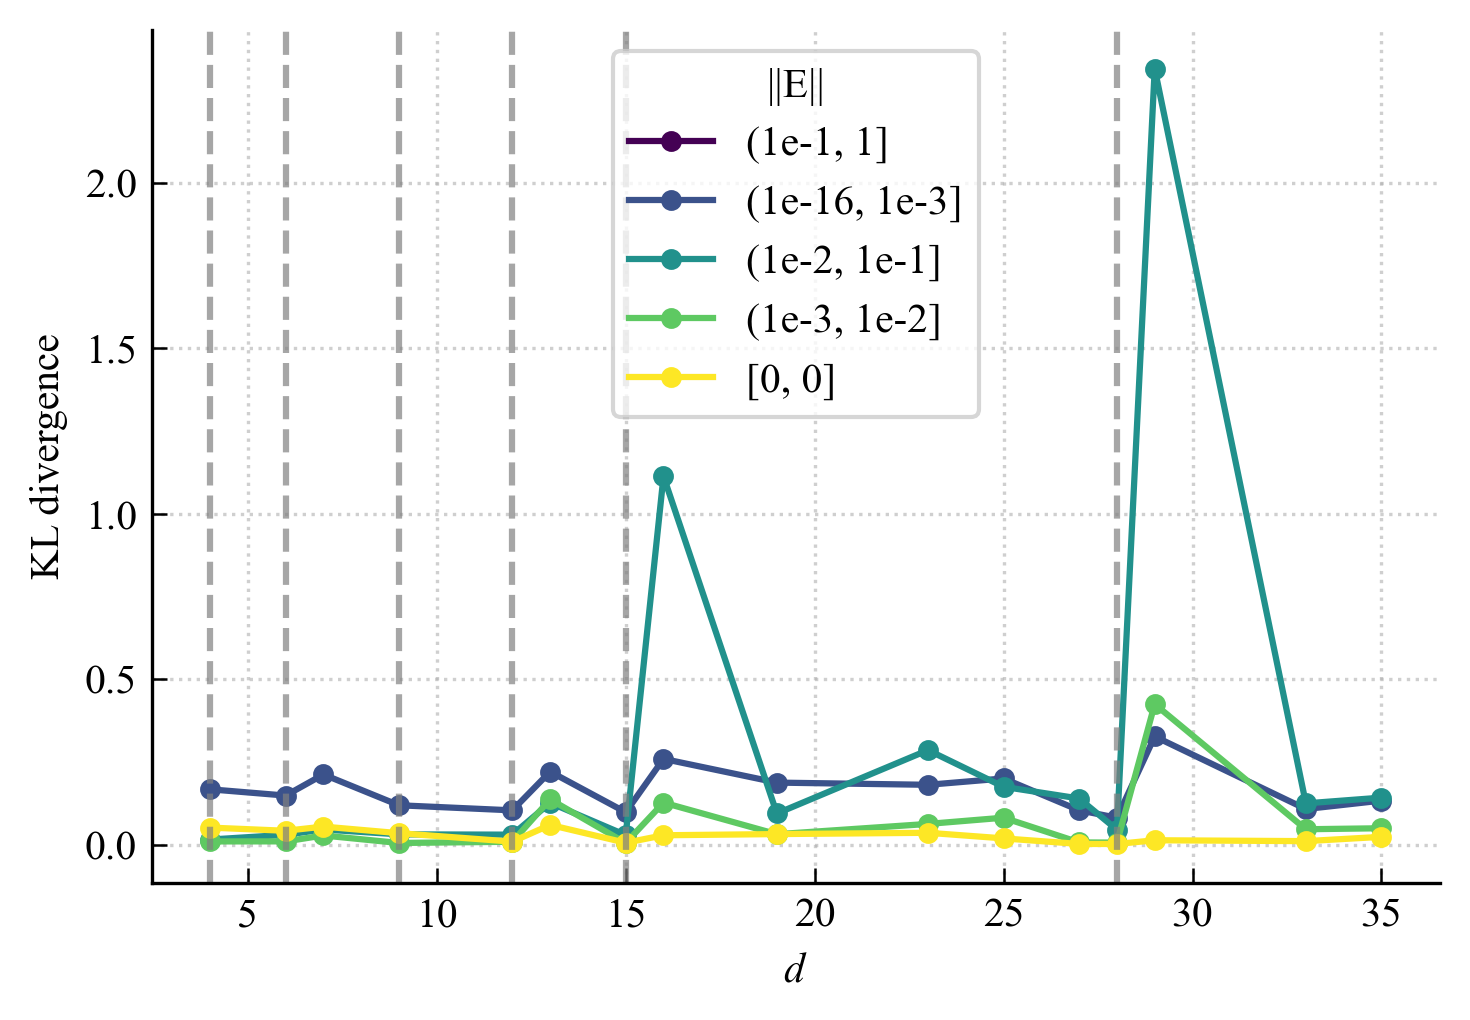

In [16]:
plot_avg_kl_vs_E(
    results,
    pretrained_dimensions=pretrained_dimensions
)

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def plot_avg_kl_vs_rad(
    results_dict,
    pretrained_dimensions=None
):
    """
    Plot average KL divergence vs dimension d for rad bins.
    """

    # Correct bin setup: N edges -> N-1 labels
    bin_edges = [0, 1e-8, 0.1, 0.4, 0.7, 1]
    bin_labels = [
        "[0, 1e-8]",
        "(1e-8, 0.1]",
        "(0.1, 0.4]",
        "(0.4, 0.7]",
        "(0.7, 1]",
    ]

    rows = []

    for d, df in results_dict.items():
        df = df.copy()

        df["rad_bin"] = pd.cut(
            df["rad"],
            bins=bin_edges,
            labels=bin_labels,
            include_lowest=True
        )

        grouped = df.groupby("rad_bin")["kl_loss"].mean()

        for bin_name, val in grouped.items():
            rows.append({
                "d": d,
                "rad_bin": bin_name,
                "avg_kl": val
            })

    plot_df = pd.DataFrame(rows)

    # Keep bins in desired order
    keep_bins = bin_labels
    plot_df = plot_df[plot_df["rad_bin"].isin(keep_bins)]

    # Pivot
    pivot = plot_df.pivot(index="d", columns="rad_bin", values="avg_kl")
    pivot = pivot.sort_index()

    # Ensure column order
    pivot = pivot[keep_bins]

    # Plot
    plt.figure()

    cmap = plt.cm.viridis
    colors = cmap(np.linspace(0, 1, len(pivot.columns)))

    for color, col in zip(colors, pivot.columns):
        plt.plot(pivot.index, pivot[col], marker='o', label=col, color=color)

    # Vertical lines for pretrained dimensions
    if pretrained_dimensions is not None:
        for d_val in pretrained_dimensions:
            plt.axvline(x=d_val, linestyle="--", color="grey", alpha=0.7)

    plt.xlabel("$d$")
    plt.ylabel("KL divergence")
    plt.legend(title="$\\rho(N)$", loc="upper left")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.yscale("log")

    plt.tight_layout()
    plt.savefig("latex/images/j8_a_loss.pdf")
    plt.show()

C:\Users\micha\AppData\Local\Temp\ipykernel_6460\1644105040.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("rad_bin")["kl_loss"].mean()
C:\Users\micha\AppData\Local\Temp\ipykernel_6460\1644105040.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("rad_bin")["kl_loss"].mean()
C:\Users\micha\AppData\Local\Temp\ipykernel_6460\1644105040.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence t

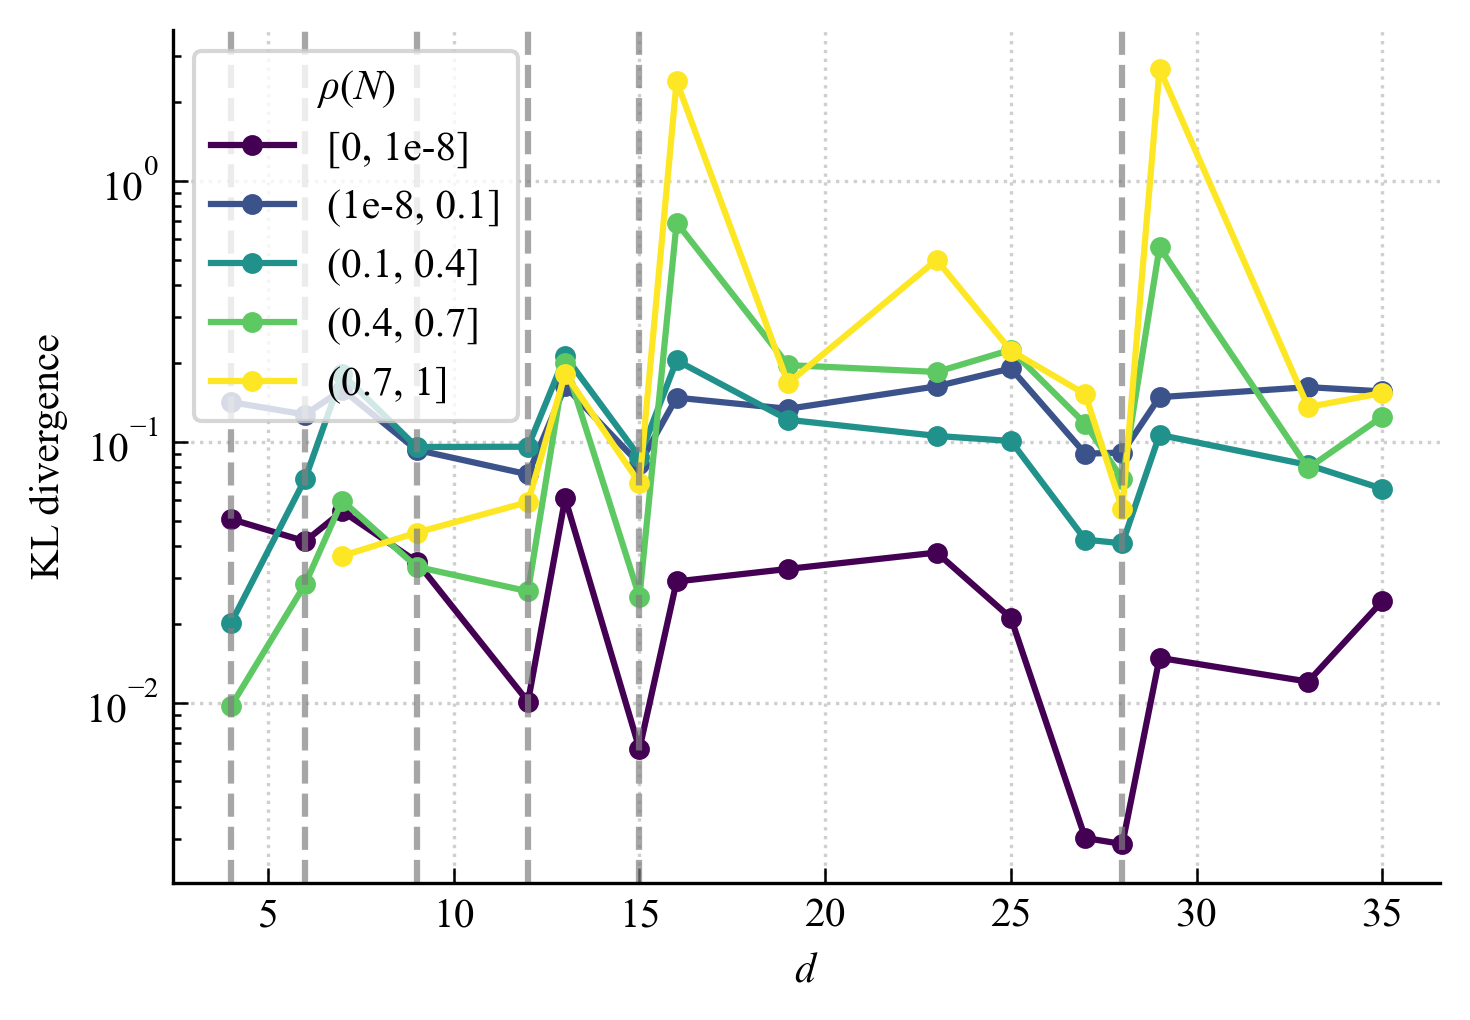

In [18]:
plot_avg_kl_vs_rad(
    results,
    pretrained_dimensions=pretrained_dimensions
)